In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

import sys
sys.path.append("./src")

from src.utils import (compute_individual_expectation_values, build_hva_layers, 
                       build_sparse_hamiltonian,find_best_initial_params,
                       test_energy_consistency,optimize_energy, 
                       compute_error, compute_energy, get_backend_info)

from qiskit import QuantumCircuit, transpile
from qiskit_aer import Aer, AerSimulator
from qiskit.providers.fake_provider import GenericBackendV2
from qiskit_ibm_runtime.fake_provider import FakeWashingtonV2, FakeAthensV2

from matplotlib import pyplot as plt
import sys
import numpy as np
from qiskit.quantum_info import Pauli, Statevector
from qiskit_aer.noise import NoiseModel, pauli_error
from qiskit.visualization import plot_gate_map
from qiskit.transpiler import CouplingMap

import pickle


sys.path.append("../../pauli_lindblad_per/")
from tomography.experiment import SparsePauliTomographyExperiment as tomography

plt.style.use("ggplot")

Initial Error: 0.10484684299231528
Exakte Energie:  -7.819890870294845
Optimierte Parameter: [-3.14159265 -1.57071519  1.57085478]
Minimaler Fehler: 0.1048468493862667


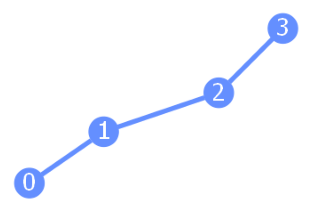

In [2]:
coupling = CouplingMap(couplinglist=[(0, 1), (1, 2), (2, 3)])
backend = GenericBackendV2(num_qubits=4, coupling_map=coupling)

num_qubits, coupling_map = get_backend_info(backend)
plot_gate_map(backend)

hx = 1
hz = 1
J= -1
H_sparse = build_sparse_hamiltonian(hx, hz, backend, J=J)

best_guess, energy_exact = find_best_initial_params(H_sparse, backend)

opt_params, min_error = optimize_energy(best_guess, H_sparse, backend, energy_exact)

expectation_values, paulis = compute_individual_expectation_values(opt_params, backend, hx, hz,J=J, num_layers=1)

print(f"Initial Error: {compute_error(best_guess, H_sparse, backend, energy_exact, num_layers=1)}")
print("Exakte Energie: ", energy_exact)
print("Optimierte Parameter:", opt_params)
print("Minimaler Fehler:", min_error)

In [3]:
inst_map = [0,1,2,3]
expectation_values, paulis = compute_individual_expectation_values(opt_params, backend, hx, hz,J=J, num_layers=1, inst_map=inst_map)
pauli_list = paulis
print(pauli_list)
test_energy_consistency(opt_params, backend, hx=hx, hz=hz, J=J)

['IIZZ', 'IZZI', 'ZZII', 'IIIX', 'IIIZ', 'IIXI', 'IIZI', 'IXII', 'IZII', 'XIII', 'ZIII']
Energie direkt        : -6.9999999500
Energie aus Summe     : -6.9999999500+0.0000000000j
Relativer Fehler      : 0.00e+00


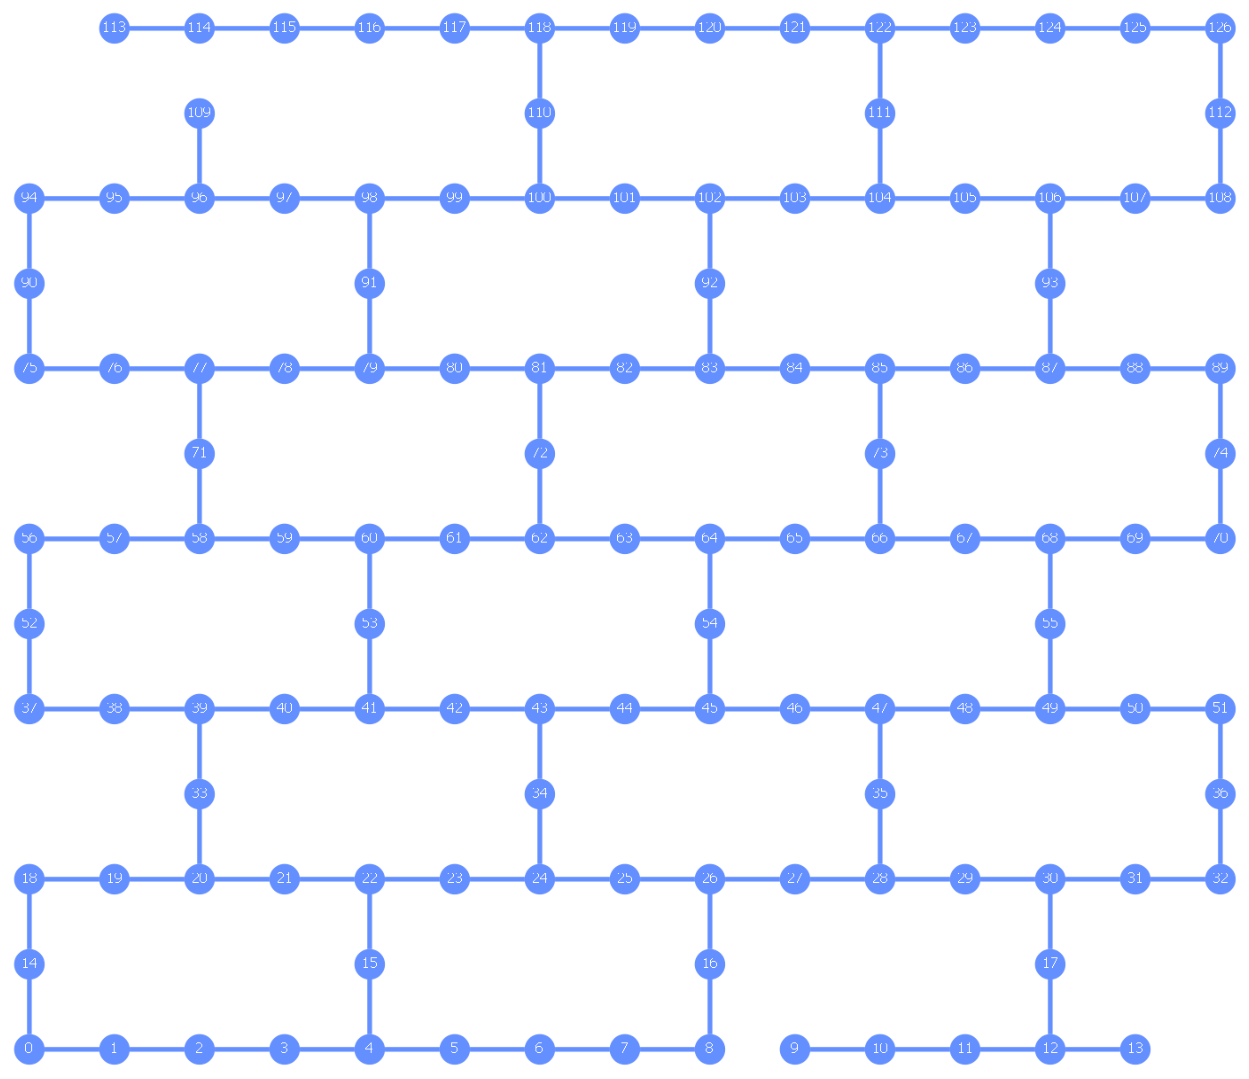

In [4]:
backend = FakeWashingtonV2()
plot_gate_map(backend)
"""coupling_list = backend.configuration().coupling_map
print("Coupling Map:", coupling_list)"""

noise_model = NoiseModel.from_backend(backend)
simulator = AerSimulator.from_backend(backend)

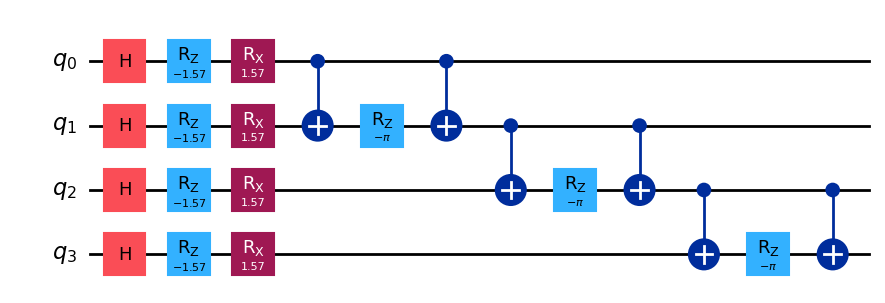

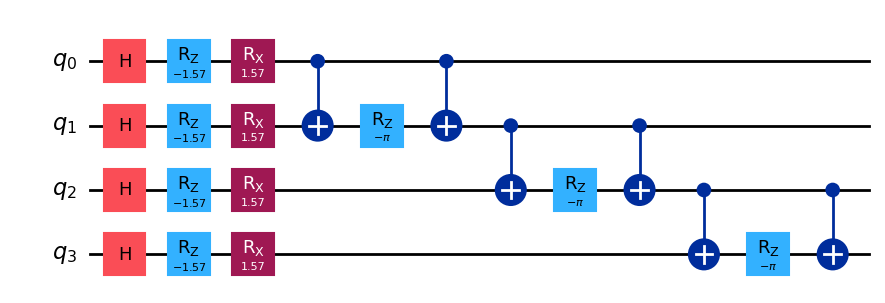

In [5]:
qc = build_hva_layers(opt_params, backend, inst_map=inst_map, num_layers=1)

qc.draw('mpl')

In [6]:
experiment = tomography(
    circuits = [qc], #list of circuits from which to get the layers requiring tomography
    inst_map = inst_map, #which physical qubits on the processor to map the qubits in the circuit
    backend = backend, #quantum backend
    used_qubits= inst_map
    )

experiment.generate(
    samples = 100, #Number of samples to take from the fidelity pair measurements
    single_samples = 250, #samples to take from the pair-breaking measurements
    depths = [2,4,16,32,64] #values of 2n to make the pair measurements. Numbers must be even and non-zero
    )

shots = 1024
def executor(circuits):
    return backend.run(circuits, shots = shots, noise_model=noise_model).result().get_counts()

#run the experiment
experiment.run(executor)
noisedataframe = experiment.analyze()

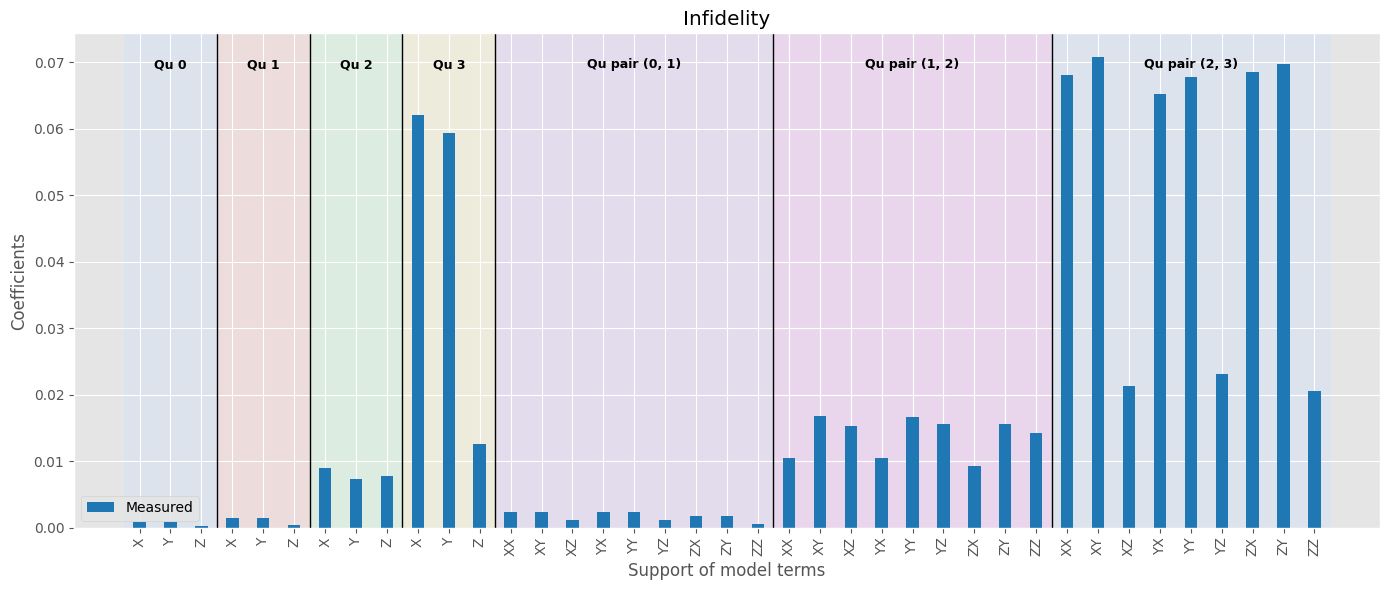

In [7]:
layer1 = experiment.analysis.get_layer_data(0)
layer1.plot_infidelitites(plot_style = 2)

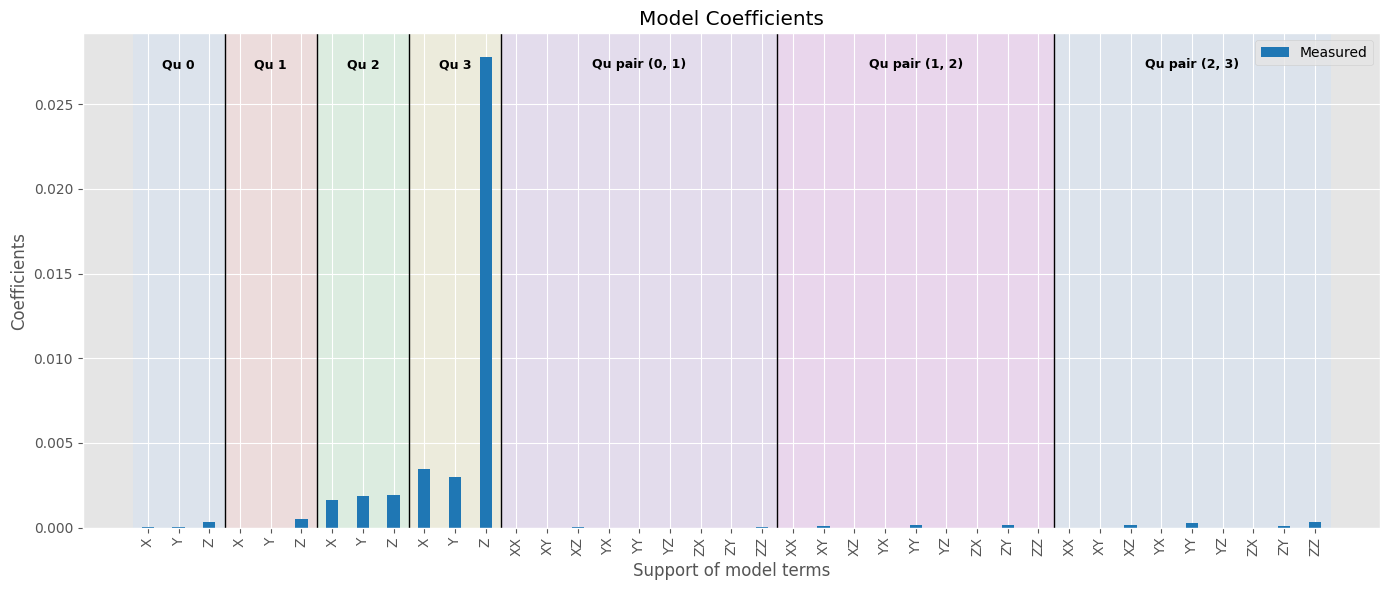

In [8]:
layer1.plot_coeffs(plot_style = 2)

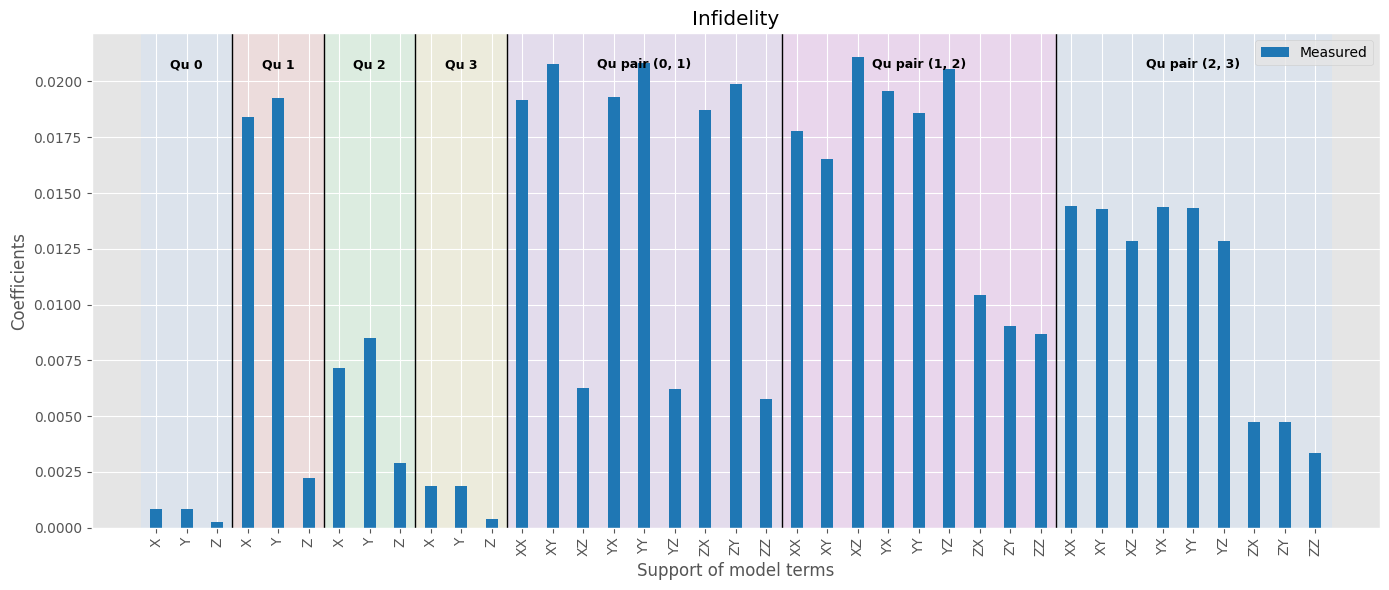

In [9]:
layer2 = experiment.analysis.get_layer_data(1)
layer2.plot_infidelitites(plot_style = 2)

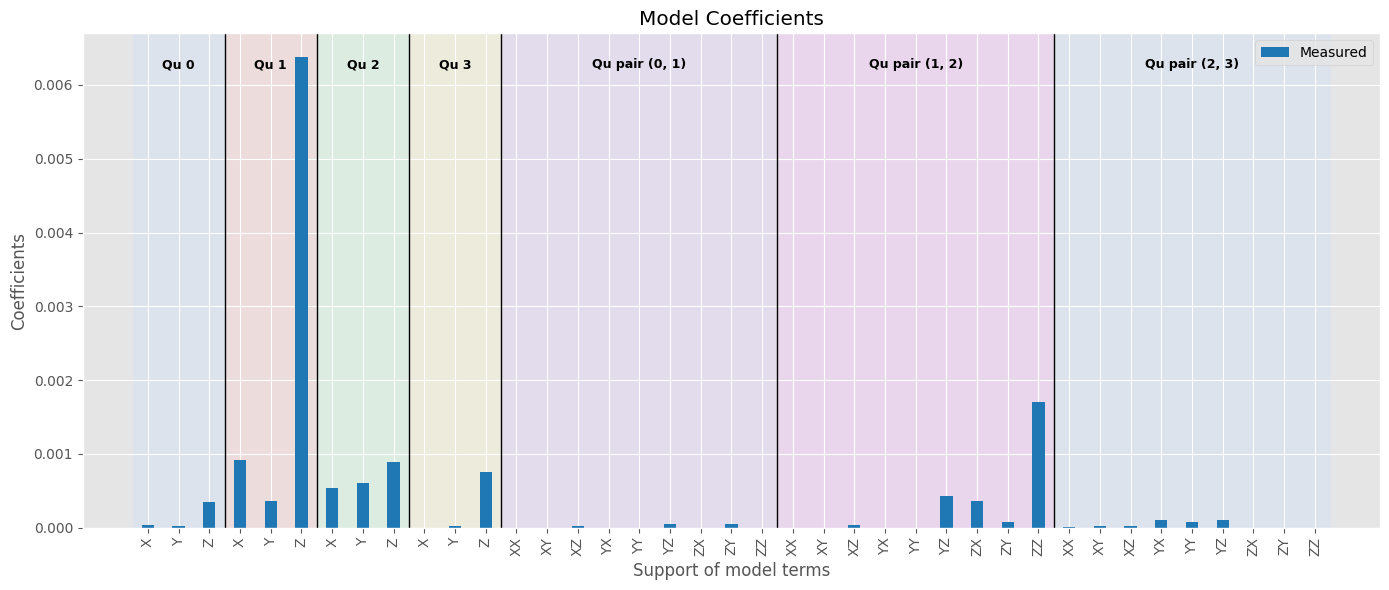

In [10]:
layer2.plot_coeffs(plot_style = 2)

In [11]:
# 2. PER-Experiment Setup
perexp = experiment.create_per_experiment([qc])

perexp.generate(
    expectations=pauli_list,
    samples=1000,
    noise_strengths=[0, 1, 2]
)

# 3. Ausführen
perexp.run(executor)
per_results = perexp.analyze()

In [12]:
# Compare absolute vs relative errors
for k in range(len(pauli_list)):
    exact = expectation_values[k]
    calc = per_results[0].get_result(pauli_list[k]).get_expectations()[0]
    abs_error = abs(exact - calc)
    rel_error = abs_error / abs(exact) if exact != 0 else float('inf')
    
    print(f"{pauli_list[k]}: Exact={exact:.4f}, Calc={calc:.4f}")
    print(f"  Absolute error: {abs_error:.6f}")
    print(f"  Relative error: {rel_error*100:.2f}%")
    print()

IIZZ: Exact=1.0000, Calc=0.9203
  Absolute error: 0.079745
  Relative error: 7.97%

IZZI: Exact=1.0000, Calc=0.9202
  Absolute error: 0.079777
  Relative error: 7.98%

ZZII: Exact=1.0000, Calc=0.9071
  Absolute error: 0.092943
  Relative error: 9.29%

IIIX: Exact=-0.0001, Calc=0.0018
  Absolute error: 0.001882
  Relative error: 2319.12%

IIIZ: Exact=-1.0000, Calc=-0.9256
  Absolute error: 0.074383
  Relative error: 7.44%

IIXI: Exact=0.0001, Calc=-0.0003
  Absolute error: 0.000350
  Relative error: 431.42%

IIZI: Exact=-1.0000, Calc=-0.9291
  Absolute error: 0.070945
  Relative error: 7.09%

IXII: Exact=0.0001, Calc=0.0018
  Absolute error: 0.001690
  Relative error: 2083.26%

IZII: Exact=-1.0000, Calc=-0.9127
  Absolute error: 0.087285
  Relative error: 8.73%

XIII: Exact=-0.0001, Calc=-0.0016
  Absolute error: 0.001533
  Relative error: 1889.24%

ZIII: Exact=-1.0000, Calc=-0.9062
  Absolute error: 0.093818
  Relative error: 9.38%

